# Efficiency vs. Accuracy Analysis
Combines the parameter-count / inference-time measurements from
`SigTest_Part1_Predictions.ipynb` and `SigTest_Part2_LeViT.ipynb` with the
known test-set accuracy of each model, and the proposed ensemble
(Swin + ViT + ResNet50). Produces a summary table and a scatter plot for
the thesis. No GPU needed -- this only reads small CSVs already saved to Drive.

## Cell 1 — Load and combine the efficiency measurements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

cache = '/content/drive/MyDrive/thesis_ensemble_outputs/significance_test_cache'

eff1 = pd.read_csv(f'{cache}/efficiency_part1.csv')   # Swin, ViT, ResNet50, DenseNet121, EfficientNetB0
eff2 = pd.read_csv(f'{cache}/efficiency_part2.csv')   # LeViT

eff_df = pd.concat([eff1, eff2], ignore_index=True)
print(eff_df.to_string(index=False))

Mounted at /content/drive
         Model   Params  ms_per_image
          Swin 27719302     21.016673
           ViT 85998604     14.246651
      ResNet50 24115340     11.339557
   DenseNet121  7302988     15.775140
EfficientNetB0  4380591     10.690421
         LeViT  8591116      8.758936


## Cell 2 — Add known accuracy, compute the proposed ensemble's totals
Accuracy values are the simple-average test accuracies already established
earlier in this study. Update these if your numbers differ.

In [2]:
known_accuracy = {
    "Swin": 0.9823,
    "ViT": 0.9838,
    "LeViT": 0.9511,
    "ResNet50": 0.9795,
    "DenseNet121": 0.9689,
    "EfficientNetB0": 0.9768,
}

eff_df["Accuracy"] = eff_df["Model"].map(known_accuracy)

# Proposed ensemble = Swin + ViT + ResNet50 run sequentially -> params and
# inference time both ADD UP (all three must be loaded and run per prediction)
ensemble_components = eff_df[eff_df["Model"].isin(["Swin", "ViT", "ResNet50"])]
ensemble_row = pd.DataFrame([{
    "Model": "Proposed Ensemble",
    "Params": int(ensemble_components["Params"].sum()),
    "ms_per_image": float(ensemble_components["ms_per_image"].sum()),
    "Accuracy": 0.9886,   # Swin+ViT+ResNet50 simple-average ensemble test accuracy
}])

full_df = pd.concat([eff_df, ensemble_row], ignore_index=True)
full_df["Params (M)"] = (full_df["Params"] / 1e6).round(2)
full_df["Accuracy (%)"] = (full_df["Accuracy"] * 100).round(2)
full_df["Inference (ms/img)"] = full_df["ms_per_image"].round(2)

summary = full_df[["Model", "Params (M)", "Inference (ms/img)", "Accuracy (%)"]]
print(summary.to_string(index=False))

            Model  Params (M)  Inference (ms/img)  Accuracy (%)
             Swin       27.72               21.02         98.23
              ViT       86.00               14.25         98.38
         ResNet50       24.12               11.34         97.95
      DenseNet121        7.30               15.78         96.89
   EfficientNetB0        4.38               10.69         97.68
            LeViT        8.59                8.76         95.11
Proposed Ensemble      137.83               46.60         98.86


## Cell 3 — Save the summary table

In [3]:
output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
summary.to_csv(f'{output_folder}/efficiency_accuracy_summary.csv', index=False)
print(f"Saved to: {output_folder}/efficiency_accuracy_summary.csv")

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/efficiency_accuracy_summary.csv


## Cell 4 — Scatter plot: accuracy vs. inference time (bubble size = parameters)
Sized for a paper figure. The ideal region is top-left (fast + accurate);
bubble size shows the memory/compute footprint.

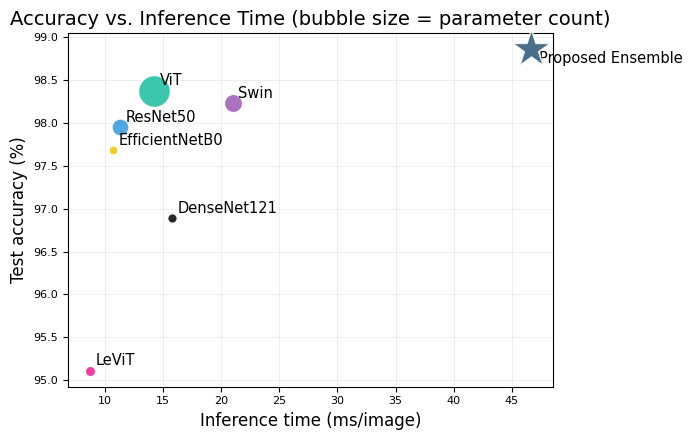

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/efficiency_accuracy_scatter.png


In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))

model_colors = {
    "Proposed Ensemble": "#2A5674",# till
"Swin":               "#9B59B6",  # bright purple
"ViT":                "#1ABC9C",  # bright teal
"ResNet50":           "#3498DB",  # bright blue
"EfficientNetB0":     "#F1C40F",  # golden yellow
"DenseNet121":        "#000000",  # dark navy/slate
"LeViT":              "#E91E8C",  # bright pink
}

sizes = (full_df["Params (M)"] * 6).clip(lower=40)

for idx, row in full_df.iterrows():
    color = model_colors.get(row["Model"], "#8C8C8C")
    is_prop = row["Model"] == "Proposed Ensemble"
    ax.scatter(row["Inference (ms/img)"], row["Accuracy (%)"],
               s=sizes[idx], color=color, alpha=0.85,
               edgecolors='white', linewidth=1.2 if is_prop else 0.8,
               marker='*' if is_prop else 'o',
               zorder=4 if is_prop else 3)

for _, row in full_df.iterrows():
    offset = (4, 4) if row["Model"] != "Proposed Ensemble" else (6, -10)
    ax.annotate(row["Model"], (row["Inference (ms/img)"], row["Accuracy (%)"]),
                textcoords="offset points", xytext=offset, fontsize=10.5)

ax.set_xlabel('Inference time (ms/image)', fontsize=12)
ax.set_ylabel('Test accuracy (%)', fontsize=12)
ax.set_title('Accuracy vs. Inference Time (bubble size = parameter count)', fontsize=14)
ax.tick_params(labelsize=8)
ax.grid(alpha=0.3, linewidth=0.5)
# no legend — every point is already labeled directly on the chart

plt.tight_layout()
plt.savefig(f'{output_folder}/efficiency_accuracy_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to: {output_folder}/efficiency_accuracy_scatter.png")

## Cell 5 — Cost of the accuracy gain (proposed ensemble vs. its best component)

In [5]:
best_component = eff_df.loc[eff_df["Model"].isin(["Swin", "ViT", "ResNet50"]), "Accuracy"].idxmax()
best_name = eff_df.loc[best_component, "Model"]
best_acc = eff_df.loc[best_component, "Accuracy"] * 100
best_time = eff_df.loc[best_component, "ms_per_image"]
best_params = eff_df.loc[best_component, "Params"] / 1e6

ens_acc = float(ensemble_row["Accuracy"].iloc[0]) * 100
ens_time = float(ensemble_row["ms_per_image"].iloc[0])
ens_params = float(ensemble_row["Params"].iloc[0]) / 1e6

print(f"Best single component: {best_name} -- {best_acc:.2f}% accuracy, {best_time:.2f} ms/image, {best_params:.1f}M params")
print(f"Proposed Ensemble:      {ens_acc:.2f}% accuracy, {ens_time:.2f} ms/image, {ens_params:.1f}M params")
print()
print(f"Accuracy gain:      +{ens_acc - best_acc:.2f} percentage points")
print(f"Extra latency:       {ens_time - best_time:.2f} ms/image  ({(ens_time/best_time - 1)*100:.0f}% slower)")
print(f"Extra parameters:    {ens_params - best_params:.1f}M more  ({(ens_params/best_params - 1)*100:.0f}% larger)")

Best single component: ViT -- 98.38% accuracy, 14.25 ms/image, 86.0M params
Proposed Ensemble:      98.86% accuracy, 46.60 ms/image, 137.8M params

Accuracy gain:      +0.48 percentage points
Extra latency:       32.36 ms/image  (227% slower)
Extra parameters:    51.8M more  (60% larger)
